# CPIC on Drift-Diffusion Data Generation

In [ ]:
import numpy as np
import torch

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
from IPython.display import HTML

import sys
from pathlib import Path
print(sys.executable)

# Paths: experiment (for generate_drift_diffusion), and src (for cpic package)
experiment_path = Path("../experiments/drift_diffusion_experiment").resolve()
src_path = Path("../src").resolve()
for p in (experiment_path, src_path):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from generate_drift_diffusion import (
    generate_drift_diffusion_positions,
    generate_drift_diffusion_process_timeseries,
    animate_drift_diffusion_process,
    plot_verification_3d)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from cpic import CPIC
from cpic.utils.data import PastFutureDataset

/Users/phoenixpham/Desktop/CPIC_dev/.venv/bin/python


# Simulate the Drift-Diffusion Data Generation Process

In [2]:
num_noise = 50  # modify depending on how much noise you want

In [ ]:
ani = animate_drift_diffusion_process(t_max=200, 
                                      num_blob=30, 
                                      num_noise=num_noise, 
                                      orbit_radius=3.0, 
                                      omega=0.05, 
                                      sigma_blob=0.1, 
                                      sigma_noise=0.5, 
                                      spatial_bounds=10.0,
                                      seed=42, 
                                      interval=50)
plt.close(ani._fig)
HTML(ani.to_jshtml())

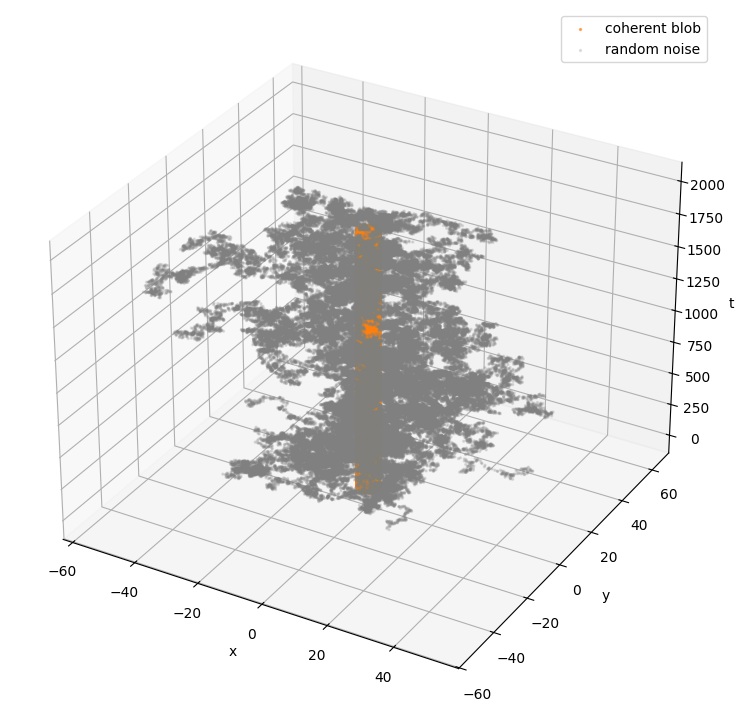

In [3]:
positions = generate_drift_diffusion_positions(t_max=2000,
                                               num_blob=30,
                                               num_noise=num_noise,
                                               orbit_radius=3.0,
                                               omega=0.05,
                                               sigma_blob=0.1,
                                               sigma_noise=0.5,
                                               spatial_bounds=10.0,
                                               seed=42)
fig, ax = plot_verification_3d(positions, num_blob=30, num_noise=num_noise)
plt.show()

# Generate the Data (interleaved particle timeseries)

Observations are shape `(t_max, N*2)`: particles sorted by **x at t=0**, columns `[x0,y0,x1,y1,...]`, z-scored per column. CPIC uses this as `xdim = N*2`.


In [4]:
data, gt_latent, particle_order, particle_labels = generate_drift_diffusion_process_timeseries(
    t_max=2000,
    num_blob=30,
    num_noise=num_noise,
    orbit_radius=3.0,
    omega=0.05,
    sigma_blob=0.1,
    sigma_noise=0.5,
    spatial_bounds=10.0,
    seed=42,
)
n_spatial = data.shape[1]
print("data shape", data.shape)
print("particle_order (x-sort at t=0):", particle_order.shape, "labels (blob=1/noise=0, orig order):", particle_labels.shape)


data shape (2000, 160)
particle_order (x-sort at t=0): (80,) labels (blob=1/noise=0, orig order): (80,)


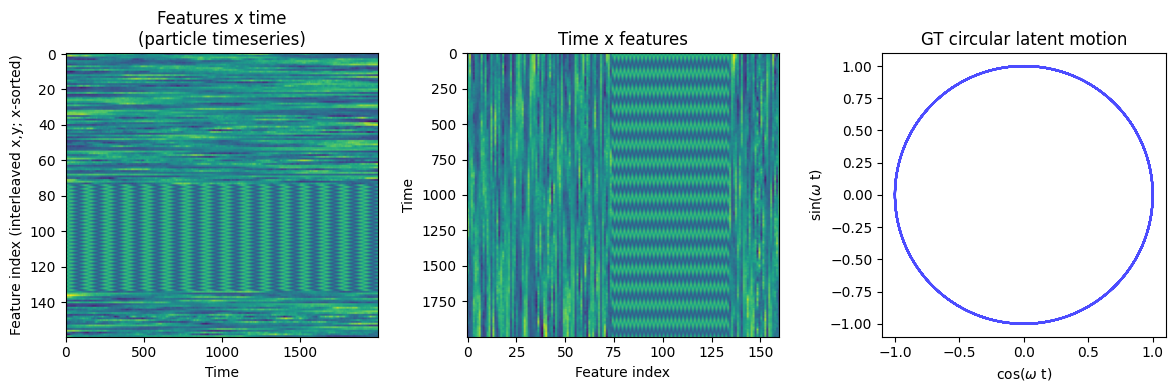

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(data.T, aspect="auto")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Feature index (interleaved x,y; x-sorted)")
axes[0].set_title("Features x time\n(particle timeseries)")

axes[1].imshow(data, aspect="auto")
axes[1].set_xlabel("Feature index")
axes[1].set_ylabel("Time")
axes[1].set_title("Time x features")

axes[2].plot(gt_latent[:, 0], gt_latent[:, 1], "b--", alpha=0.7)
axes[2].set_xlabel("cos($\omega$ t)")
axes[2].set_ylabel("sin($\omega$ t)")
axes[2].set_aspect("equal")
axes[2].set_title("GT circular latent motion")

plt.tight_layout()
plt.show()


In [ ]:
def animate_particle_timeseries(data, interval=80):
    T, F = data.shape
    fig, ax = plt.subplots(figsize=(12, 2.5))
    lo, hi = float(data.min()), float(data.max())
    im = ax.imshow(data[0:1], aspect="auto", vmin=lo, vmax=hi, cmap="viridis")
    ax.set_xlabel("Feature index (x0,y0,x1,y1,... after x-sort at t=0)")
    ax.set_ylabel("frame")
    plt.colorbar(im, ax=ax)
    def update(frame):
        im.set_data(data[frame : frame + 1])
        ax.set_title(f"t = {frame}")
        return (im,)
    return animation.FuncAnimation(fig, update, frames=T, interval=interval, blit=False)

anim1 = animate_particle_timeseries(data)
plt.close(anim1._fig)
HTML(anim1.to_jshtml())


# Run CPIC

In [5]:
device = "cuda:0" if torch.cuda.is_available() else "mps"
print("device:", device)

device: mps


In [6]:
T = 10

# Train/test split on time to avoid probing on the same windows used for CPIC training.
t_split = int(0.7 * len(data))
if t_split <= 2*T or (len(data) - t_split) <= 2*T:
    raise ValueError("t_split must leave enough room for train/test past-future windows.")

train_data = PastFutureDataset([data[:t_split]], window_size=T)
print(f"total timesteps={len(data)}, train={t_split}, test={len(data) - t_split}")
print(f"num train past/future windows for CPIC fit: {len(train_data)}")

total timesteps=2000, train=1400, test=600
num train past/future windows for CPIC fit: 1380


### Helper functions 

In [7]:
def build_past_windows_and_gt(data, gt_latent, window_size, model, t_min=None, t_max=None):
    """Build past windows in [t_min, t_max) and align GT to each window end time."""
    n_timesteps = len(data)
    t_min = window_size if t_min is None else max(window_size, int(t_min))
    t_max = n_timesteps if t_max is None else min(n_timesteps, int(t_max))
    if t_max <= t_min:
        raise ValueError(f"Invalid time span: t_min={t_min}, t_max={t_max}")

    end_times = np.arange(t_min, t_max)
    past_windows = np.stack([data[t - window_size : t] for t in end_times], axis=0)
    past_tensor = torch.from_numpy(past_windows).float().to(device)

    with torch.no_grad():
        encoded_windows = model.encode(past_tensor) # (num_windows, T, ydim)
        z = encoded_windows[:, -1, :].cpu().numpy() # window-end latent (num_windows, ydim)

    gt = gt_latent[end_times - 1]
    return z, gt


def evaluate_probe_train_test(z_train, gt_train, z_test, gt_test, encoder_name="mlp", period_steps=None):
    """Fit probe on train latents; plot train and held-out test trajectories side by side."""
    reg = LinearRegression().fit(z_train, gt_train)
    pred_train = reg.predict(z_train)
    pred_test = reg.predict(z_test)

    r2_train_x = r2_score(gt_train[:, 0], pred_train[:, 0])
    r2_train_y = r2_score(gt_train[:, 1], pred_train[:, 1])
    r2_train = r2_score(gt_train, pred_train)

    r2_test_x = r2_score(gt_test[:, 0], pred_test[:, 0])
    r2_test_y = r2_score(gt_test[:, 1], pred_test[:, 1])
    r2_test = r2_score(gt_test, pred_test)

    print(f"{encoder_name} - train R^2: x={r2_train_x:.2f}, y={r2_train_y:.2f} | "
          f"test R^2: x={r2_test_x:.2f}, y={r2_test_y:.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Train: GT vs probe prediction (same regressor, evaluated on train z)
    ax = axes[0]
    ax.plot(gt_train[:, 0], gt_train[:, 1], "b--", label="Ground truth", linewidth=2)
    ax.plot(pred_train[:, 0], pred_train[:, 1], "r-", label=f"Predicted (train $R^2$={r2_train:.2f})")
    if period_steps is not None and period_steps > 0:
        idx_tr = np.arange(len(gt_train))
        mask_tr = (idx_tr % int(period_steps)) == 0
        ax.scatter(gt_train[mask_tr, 0], gt_train[mask_tr, 1], c="navy", s=20, marker="x", label="GT period marks")
        ax.scatter(pred_train[mask_tr, 0], pred_train[mask_tr, 1], c="darkred", s=20, marker="x", label="Pred period marks")
    ax.set_title(f"Training set (first {len(gt_train)} windows)\n{encoder_name} encoder")
    ax.axis("equal")
    ax.legend(loc="upper right", fontsize=8)

    # Test: same regressor, held-out z
    ax = axes[1]
    ax.plot(gt_test[:, 0], gt_test[:, 1], "b--", label="Ground truth", linewidth=2)
    ax.plot(pred_test[:, 0], pred_test[:, 1], "r-", label=f"Predicted (test $R^2$={r2_test:.2f})")
    if period_steps is not None and period_steps > 0:
        idx_te = np.arange(len(gt_test))
        period_mask = (idx_te % int(period_steps)) == 0
        ax.scatter(gt_test[period_mask, 0], gt_test[period_mask, 1], c="navy", s=20, marker="x", label="GT period marks")
        ax.scatter(pred_test[period_mask, 0], pred_test[period_mask, 1], c="darkred", s=20, marker="x", label="Pred period marks")
    ax.set_title(f"Test set (held-out) (last {len(gt_test)} windows)\n{encoder_name} encoder")
    ax.axis("equal")
    ax.legend(loc="upper right", fontsize=8)
    
    fig.suptitle("CPIC linear probe (fit on train latents; test uses same regressor)", y=1.02)
    fig.tight_layout()
    plt.show()

    return {"r2_train": r2_train, "r2_train_x": r2_train_x, "r2_train_y": r2_train_y, 
            "r2_test": r2_test, "r2_test_x": r2_test_x, "r2_test_y": r2_test_y
            }


In [8]:
import gc

def cleanup_torch(verbose=True):
    """Release Python refs and ask torch backends to free cached memory."""
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        if verbose:
            alloc = torch.cuda.memory_allocated() / (1024 ** 2)
            reserved = torch.cuda.memory_reserved() / (1024 ** 2)
            print(f"[cleanup] CUDA allocated={alloc:.1f} MB, reserved={reserved:.1f} MB")
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        if verbose:
            print("[cleanup] MPS backend active (no torch empty_cache equivalent).")
    elif verbose:
        print("[cleanup] CPU backend active.")


def cleanup_model_resources(*objs, verbose=True):
    """Drop references to large training objects, then clear backend caches."""
    for obj in objs:
        del obj
    cleanup_torch(verbose=verbose)

## MLP encoder

In [9]:
encoder_params = {
    "deterministic": False,
    "encoder_type": "mlp",
    "linear_encoder": False,
    "n_layers": 1,
    "activation": "relu",
}

In [10]:
cpic = CPIC(ydim=2, xdim=n_spatial, T=T, encoder_params=encoder_params, hidden_dim=64, beta=1e-5, device=device)
cpic.to(device);

In [11]:
loss, I_compress, I_predictive = cpic.fit(X=train_data, epochs=80, batch_size=256, lr=2e-4, early_stop=20)

  0%|          | 0/80 [00:00<?, ?it/s]

  2%|▎         | 2/80 [00:00<00:20,  3.73it/s]

Epoch 0: loss=0.0018, I_compress_bound=0.3800, I_predictive_bound=-0.0018
Epoch 1: loss=0.0013, I_compress_bound=0.3242, I_predictive_bound=-0.0013


  5%|▌         | 4/80 [00:00<00:13,  5.68it/s]

Epoch 2: loss=0.0015, I_compress_bound=0.4192, I_predictive_bound=-0.0015
Epoch 3: loss=-0.0001, I_compress_bound=0.3786, I_predictive_bound=0.0001


...

Epoch 75: loss=-5.1789, I_compress_bound=5.3885, I_predictive_bound=5.1790
Epoch 76: loss=-5.2029, I_compress_bound=5.3885, I_predictive_bound=5.2029


 99%|█████████▉| 79/80 [00:09<00:00,  8.50it/s]

Epoch 77: loss=-5.1962, I_compress_bound=5.3885, I_predictive_bound=5.1963
Epoch 78: loss=-5.1876, I_compress_bound=5.3885, I_predictive_bound=5.1877


100%|██████████| 80/80 [00:09<00:00,  8.41it/s]

Epoch 79: loss=-5.1868, I_compress_bound=5.3885, I_predictive_bound=5.1868


MLP - train R^2: x=0.86, y=0.87 | test R^2: x=0.16, y=0.15


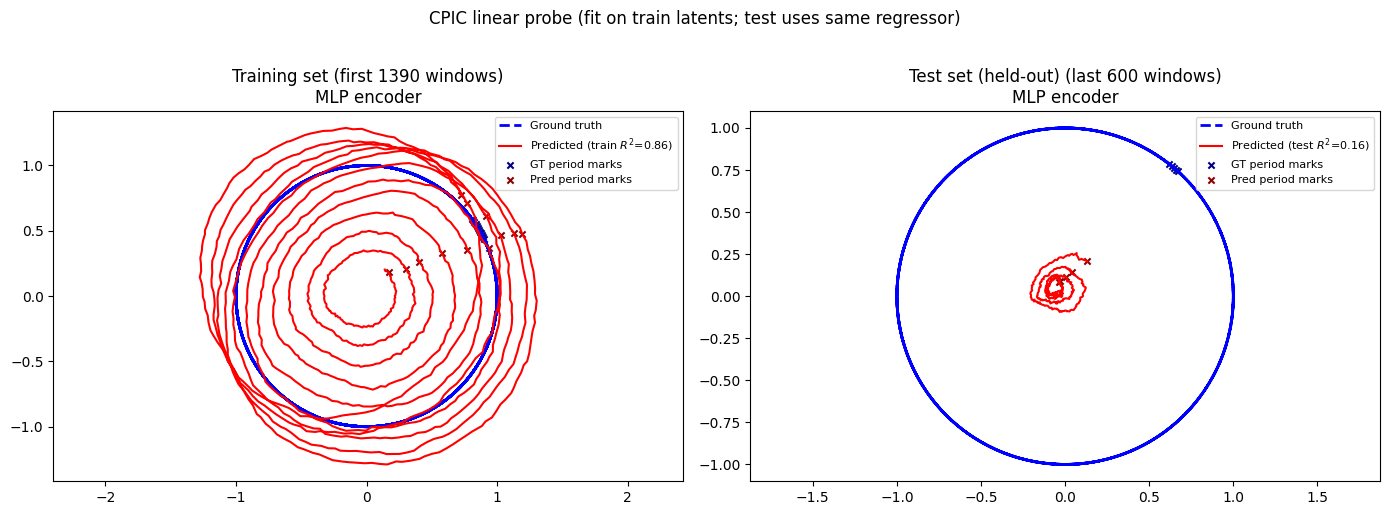

In [12]:
period_steps = int(round((2 * np.pi) / 0.05))

z_train, gt_train = build_past_windows_and_gt(data, gt_latent, T, cpic, t_min=T, t_max=t_split)
z_test, gt_test = build_past_windows_and_gt(data, gt_latent, T, cpic, t_min=t_split, t_max=len(data))

mlp_metrics = evaluate_probe_train_test(
    z_train,
    gt_train,
    z_test,
    gt_test,
    encoder_name="MLP",
    period_steps=period_steps,
)

In [13]:
cleanup_model_resources(cpic, loss, I_compress, I_predictive)

[cleanup] MPS backend active (no torch empty_cache equivalent).


## ConvSpatial (Latent predictive space) encoder

`conv_spatial` applies Conv2d along the **feature** axis (particle channels), suitable for the `(t_max, N*2)` interleaved representation.


In [14]:
encoder_params = {
    "deterministic": False,
    "encoder_type": "conv_spatial",
    "linear_encoder": False,
    "n_layers": 1,
    "activation": "relu",
    "conv_kernel_size": 5,
    "conv_stride": 1,
    "conv_padding": 2,
}


In [15]:
cpic_conv_latent = CPIC(ydim=2, xdim=n_spatial, T=T, encoder_params=encoder_params, hidden_dim=64, beta=1e-5, device=device)
cpic_conv_latent.to(device);

In [16]:
loss, I_compress, I_predictive = cpic_conv_latent.fit(X=train_data, epochs=80, batch_size=256, lr=2e-4, early_stop=20)


  1%|▏         | 1/80 [00:02<02:52,  2.19s/it]

Epoch 0: loss=-0.0250, I_compress_bound=2.4541, I_predictive_bound=0.0251


  2%|▎         | 2/80 [00:04<02:46,  2.14s/it]

Epoch 1: loss=-0.1964, I_compress_bound=5.0864, I_predictive_bound=0.1965


  4%|▍         | 3/80 [00:06<02:42,  2.11s/it]

...

Epoch 77: loss=-5.1822, I_compress_bound=5.3885, I_predictive_bound=5.1823


 99%|█████████▉| 79/80 [02:40<00:02,  2.05s/it]

Epoch 78: loss=-5.2004, I_compress_bound=5.3885, I_predictive_bound=5.2004


100%|██████████| 80/80 [02:42<00:00,  2.03s/it]

Epoch 79: loss=-5.1986, I_compress_bound=5.3885, I_predictive_bound=5.1986


ConvSpatial (L) - train R^2: x=0.57, y=0.68 | test R^2: x=0.64, y=0.72


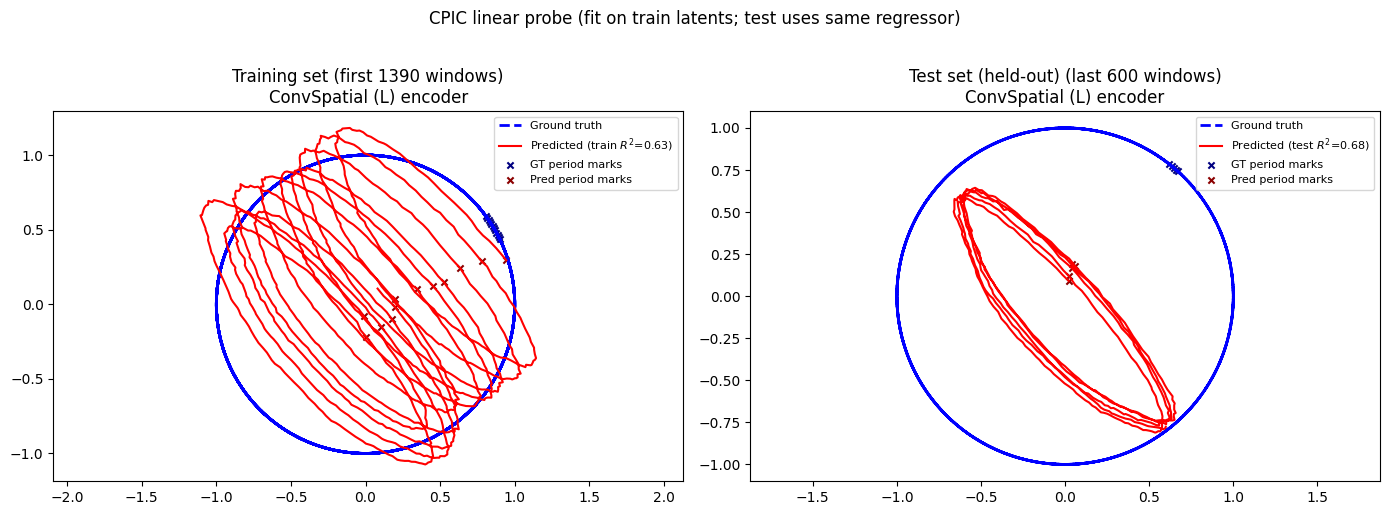

In [17]:
z_train, gt_train = build_past_windows_and_gt(data, gt_latent, T, cpic_conv_latent, t_min=T, t_max=t_split)
z_test, gt_test = build_past_windows_and_gt(data, gt_latent, T, cpic_conv_latent, t_min=t_split, t_max=len(data))

conv_latent_metrics = evaluate_probe_train_test(
    z_train,
    gt_train,
    z_test,
    gt_test,
    encoder_name="ConvSpatial (L)",
    period_steps=period_steps,
)

### Kernel / feature analysis

The kernels slide along the **feature** axis (interleaved particle coordinates).


In [18]:
enc = cpic_conv_latent.encoder
layer_idx = 0

if getattr(enc, "encoder_type", None) != "conv_spatial":
    print("Skipping kernel analysis: encoder is not conv_spatial")
else:
    w, meta = enc.get_filters(layer_idx=layer_idx)
    K_h, K_w = meta["kernel_size"]
    print(f"Layer {layer_idx} Conv2d weight shape:", w.shape, "padding:", meta["padding"], "stride:", meta["stride"])

Layer 0 Conv2d weight shape: (64, 1, 5, 1) padding: (2, 0) stride: (1, 1)


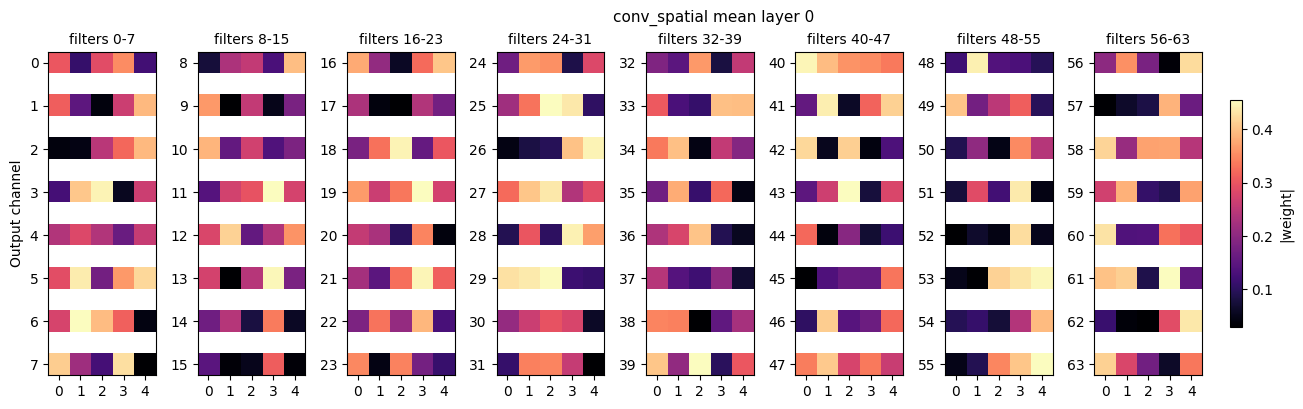

In [19]:
def _pad_filter_magnitudes(w_mag, gap_rows=1):
    """
    Helper function to pad the filter magnitudes with NaNs between filters for easier visualization.
    """
    C_out, Kh = w_mag.shape
    pad_h = C_out + (C_out - 1) * gap_rows
    pad = np.full((pad_h, Kh), np.nan, dtype=np.float64)
    for i in range(C_out):
        pad[i * (1 + gap_rows), :] = w_mag[i, :]
    return pad, C_out, Kh, gap_rows

def plot_filter_heatmap_panels(w_mag, gap_rows=1, filters_per_panel=12, suptitle=None, cell_inches=0.28):
    """
    Plot each filter magnitude as a heatmap.
    """
    C_out, Kh = w_mag.shape

    chunks = []
    for start in range(0, C_out, filters_per_panel):
        end = min(start + filters_per_panel, C_out)
        sub = w_mag[start:end, :]
        pad, c_sub, kh, g = _pad_filter_magnitudes(sub, gap_rows=gap_rows)
        chunks.append((pad, start, end, c_sub, kh, g))
    n_panels = len(chunks)
    max_pad_h = max(pad.shape[0] for pad, *_ in chunks)

    # specific fig size for this plot for better visualization
    fig_w = n_panels * (Kh * cell_inches) + max(0, n_panels - 1)
    fig_h = max_pad_h * cell_inches
    fig, axes = plt.subplots(1, n_panels, figsize=(fig_w, fig_h))

    ims = []
    for ax, (pad, start, end, c_sub, kh, g) in zip(axes.flat, chunks):
        im = ax.imshow(pad, aspect="equal", cmap="magma")
        ims.append(im)

        ax.set_xticks(np.arange(kh))
        ax.set_xticklabels([str(i) for i in range(kh)])

        ax.set_yticks([i * (1 + g) for i in range(c_sub)])
        ax.set_yticklabels([str(start + i) for i in range(c_sub)])

        ax.set_title("filters {}-{}".format(start, end - 1), fontsize=10)
    axes.flat[0].set_ylabel("Output channel")

    if suptitle:
        fig.suptitle(suptitle, fontsize=11)
        
    cbar = fig.colorbar(ims[0], ax=axes.ravel().tolist(), shrink=0.7, pad=0.02)
    cbar.set_label("|weight|")

    return fig, axes

w_mag = np.abs(w[:, 0, :, 0]) # (C_out, K_h)
fig, axes = plot_filter_heatmap_panels(w_mag, gap_rows=1, filters_per_panel=8, suptitle=f"conv_spatial mean layer {layer_idx}")
plt.show()

In [20]:
cleanup_model_resources(cpic_conv_latent, loss, I_compress, I_predictive)

[cleanup] MPS backend active (no torch empty_cache equivalent).


## ConvSpatial (Observation predictive space) encoder

In [21]:
cpic_conv_obs = CPIC(ydim=2, xdim=n_spatial, T=T, encoder_params=encoder_params, hidden_dim=64, beta=1e-5, device=device, predictive_space="observation")
cpic_conv_obs.to(device);

In [22]:
loss, I_compress, I_predictive = cpic_conv_obs.fit(X=train_data, epochs=80, batch_size=256, lr=2e-4, early_stop=20)


  1%|▏         | 1/80 [00:01<02:12,  1.68s/it]

Epoch 0: loss=-0.0128, I_compress_bound=2.6676, I_predictive_bound=0.0128


  2%|▎         | 2/80 [00:03<02:08,  1.65s/it]

Epoch 1: loss=-0.1060, I_compress_bound=4.4597, I_predictive_bound=0.1061


  4%|▍         | 3/80 [00:04<02:06,  1.65s/it]

...

Epoch 77: loss=-5.2035, I_compress_bound=5.3885, I_predictive_bound=5.2035


 99%|█████████▉| 79/80 [02:10<00:01,  1.64s/it]

Epoch 78: loss=-5.1814, I_compress_bound=5.3885, I_predictive_bound=5.1815


100%|██████████| 80/80 [02:11<00:00,  1.65s/it]

Epoch 79: loss=-5.1821, I_compress_bound=5.3885, I_predictive_bound=5.1822


ConvSpatial (O) - train R^2: x=0.57, y=0.74 | test R^2: x=0.61, y=0.80


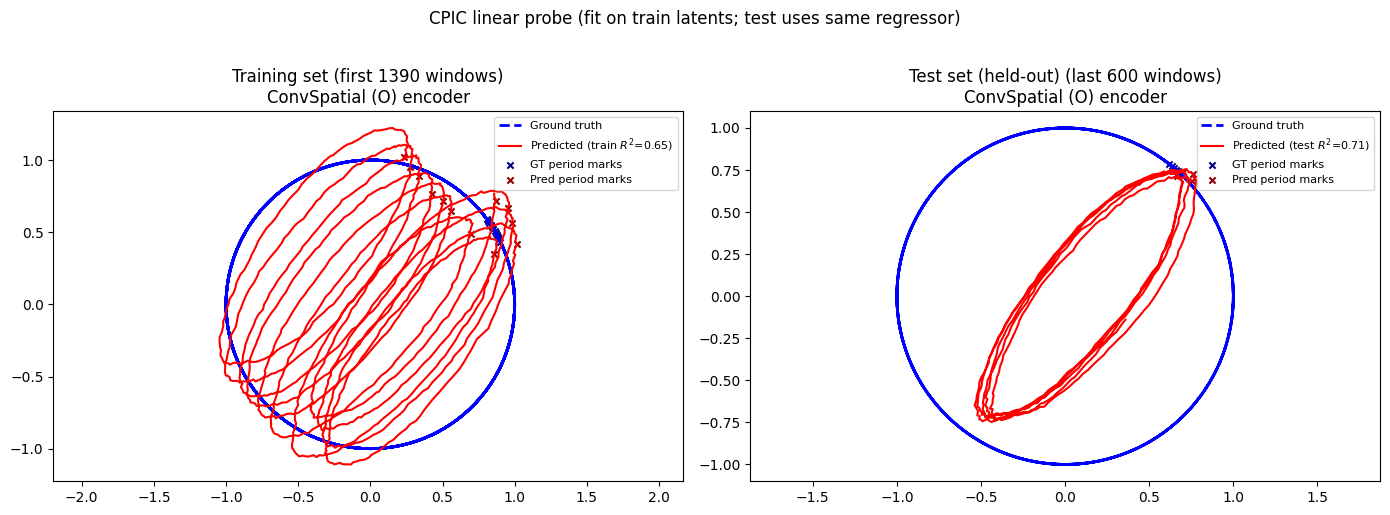

In [23]:
z_train, gt_train = build_past_windows_and_gt(data, gt_latent, T, cpic_conv_obs, t_min=T, t_max=t_split)
z_test, gt_test = build_past_windows_and_gt(data, gt_latent, T, cpic_conv_obs, t_min=t_split, t_max=len(data))

conv_obs_metrics = evaluate_probe_train_test(
    z_train,
    gt_train,
    z_test,
    gt_test,
    encoder_name="ConvSpatial (O)",
    period_steps=period_steps,
)

### Kernel / feature analysis

In [24]:
enc_obs = cpic_conv_obs.encoder
layer_idx = 0

if getattr(enc_obs, "encoder_type", None) != "conv_spatial":
    print("Skipping kernel analysis: encoder is not conv_spatial")
else:
    w, meta = enc_obs.get_filters(layer_idx=layer_idx)
    K_h, K_w = meta["kernel_size"]
    print(f"Layer {layer_idx} Conv2d weight shape:", w.shape, "padding:", meta["padding"], "stride:", meta["stride"])

Layer 0 Conv2d weight shape: (64, 1, 5, 1) padding: (2, 0) stride: (1, 1)


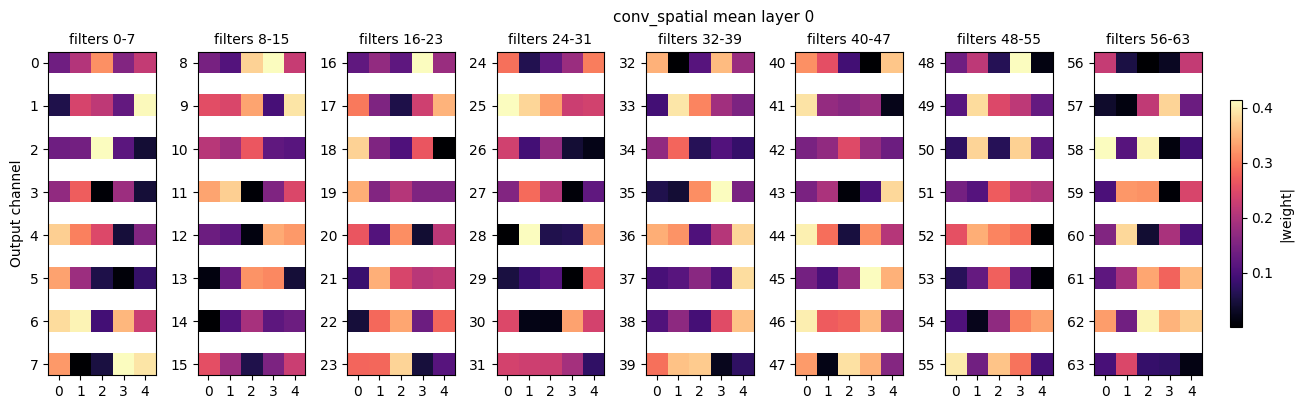

In [25]:
w_mag = np.abs(w[:, 0, :, 0]) # (C_out, K_h)
fig, axes = plot_filter_heatmap_panels(w_mag, gap_rows=1, filters_per_panel=8, suptitle=f"conv_spatial mean layer {layer_idx}")
plt.show()

In [26]:
cleanup_model_resources(cpic_conv_obs, loss, I_compress, I_predictive)

[cleanup] MPS backend active (no torch empty_cache equivalent).


## Noise Ablation Study


=== Noise condition: no_noise ===
  --- predictive_space='observation' ---
Epoch 0: loss=-0.0152, I_compress_bound=1.7216, I_predictive_bound=0.0152
Epoch 1: loss=-0.1081, I_compress_bound=3.2686, I_predictive_bound=0.1081
Epoch 2: loss=-0.2598, I_compress_bound=4.3030, I_predictive_bound=0.2599
Epoch 3: loss=-0.4443, I_compress_bound=5.0098, I_predictive_bound=0.4443
Epoch 4: loss=-0.6417, I_compress_bound=5.3096, I_predictive_bound=0.6418
Epoch 5: loss=-0.8523, I_compress_bound=5.3812, I_predictive_bound=0.8523
Epoch 6: loss=-1.0854, I_compress_bound=5.3884, I_predictive_bound=1.0855
Epoch 7: loss=-1.3428, I_compress_bound=5.3885, I_predictive_bound=1.3429
Epoch 8: loss=-1.5902, I_compress_bound=5.3885, I_predictive_bound=1.5902
Epoch 9: loss=-1.8329, I_compress_bound=5.3885, I_predictive_bound=1.8329
Epoch 10: loss=-2.0355, I_compress_bound=5.3885, I_predictive_bound=2.0356
Epoch 11: loss=-2.2442, I_compress_bound=5.3885, I_predictive_bound=2.2443
Epoch 12: loss=-2.3806, I_compress

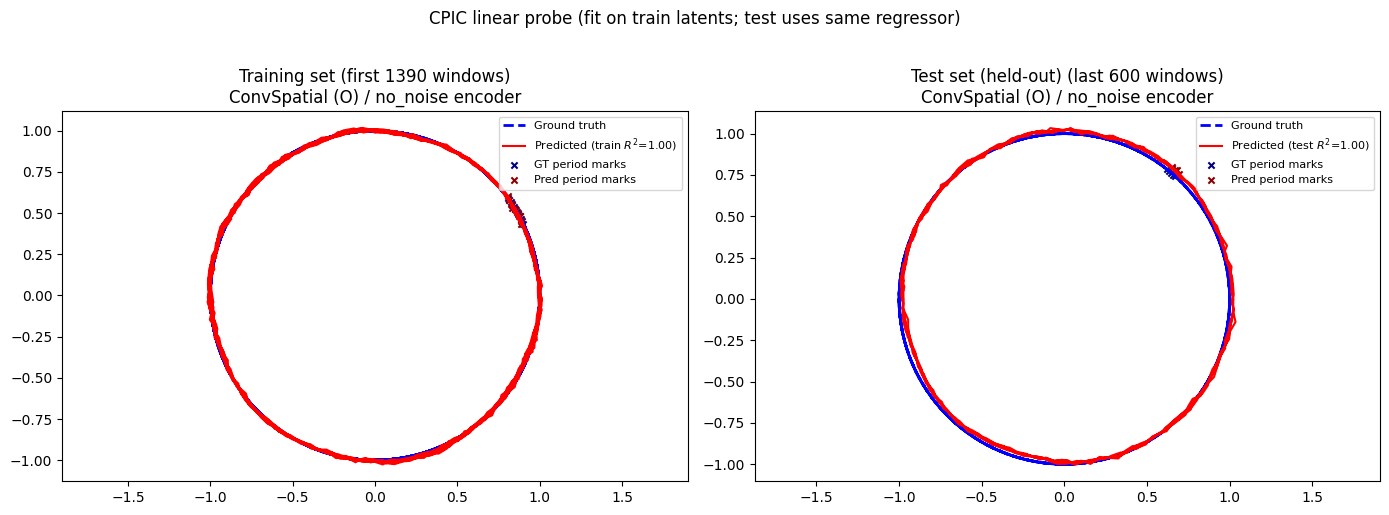

[cleanup] MPS backend active (no torch empty_cache equivalent).
  --- predictive_space='latent' ---
Epoch 0: loss=0.0007, I_compress_bound=1.1791, I_predictive_bound=-0.0007
Epoch 1: loss=-0.0172, I_compress_bound=2.5217, I_predictive_bound=0.0172
Epoch 2: loss=-0.0954, I_compress_bound=3.6315, I_predictive_bound=0.0955
Epoch 3: loss=-0.2557, I_compress_bound=4.5449, I_predictive_bound=0.2558
Epoch 4: loss=-0.4888, I_compress_bound=5.1826, I_predictive_bound=0.4888
Epoch 5: loss=-0.7491, I_compress_bound=5.3469, I_predictive_bound=0.7492
Epoch 6: loss=-1.0374, I_compress_bound=5.3811, I_predictive_bound=1.0375
Epoch 7: loss=-1.3524, I_compress_bound=5.3879, I_predictive_bound=1.3525
Epoch 8: loss=-1.6533, I_compress_bound=5.3885, I_predictive_bound=1.6534
Epoch 9: loss=-1.9370, I_compress_bound=5.3885, I_predictive_bound=1.9371
Epoch 10: loss=-2.1779, I_compress_bound=5.3885, I_predictive_bound=2.1779
Epoch 11: loss=-2.3526, I_compress_bound=5.3885, I_predictive_bound=2.3527
Epoch 12: 

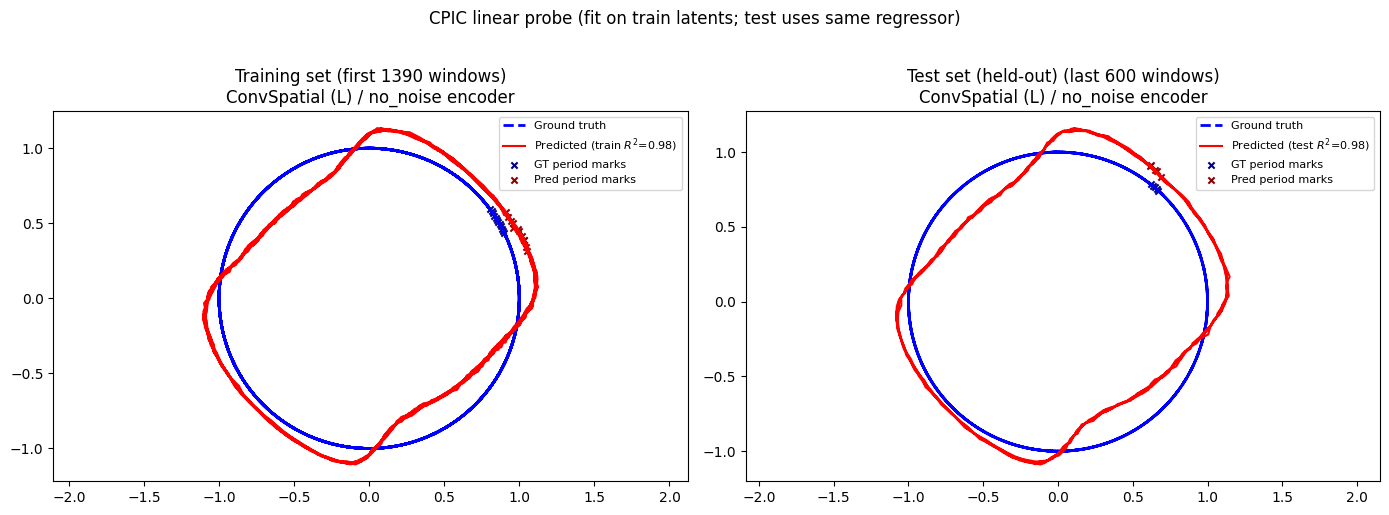

[cleanup] MPS backend active (no torch empty_cache equivalent).

=== Noise condition: high_noise ===
  --- predictive_space='observation' ---
Epoch 0: loss=-0.0218, I_compress_bound=3.0619, I_predictive_bound=0.0218
Epoch 1: loss=-0.2034, I_compress_bound=5.0125, I_predictive_bound=0.2034
Epoch 2: loss=-0.5348, I_compress_bound=5.3622, I_predictive_bound=0.5348
Epoch 3: loss=-0.9165, I_compress_bound=5.3881, I_predictive_bound=0.9165
Epoch 4: loss=-1.3127, I_compress_bound=5.3885, I_predictive_bound=1.3127
Epoch 5: loss=-1.6990, I_compress_bound=5.3885, I_predictive_bound=1.6990
Epoch 6: loss=-2.0876, I_compress_bound=5.3885, I_predictive_bound=2.0877
Epoch 7: loss=-2.4736, I_compress_bound=5.3885, I_predictive_bound=2.4737
Epoch 8: loss=-2.8503, I_compress_bound=5.3885, I_predictive_bound=2.8503
Epoch 9: loss=-3.1441, I_compress_bound=5.3885, I_predictive_bound=3.1442
Epoch 10: loss=-3.4139, I_compress_bound=5.3885, I_predictive_bound=3.4140
Epoch 11: loss=-3.6351, I_compress_bound=5.

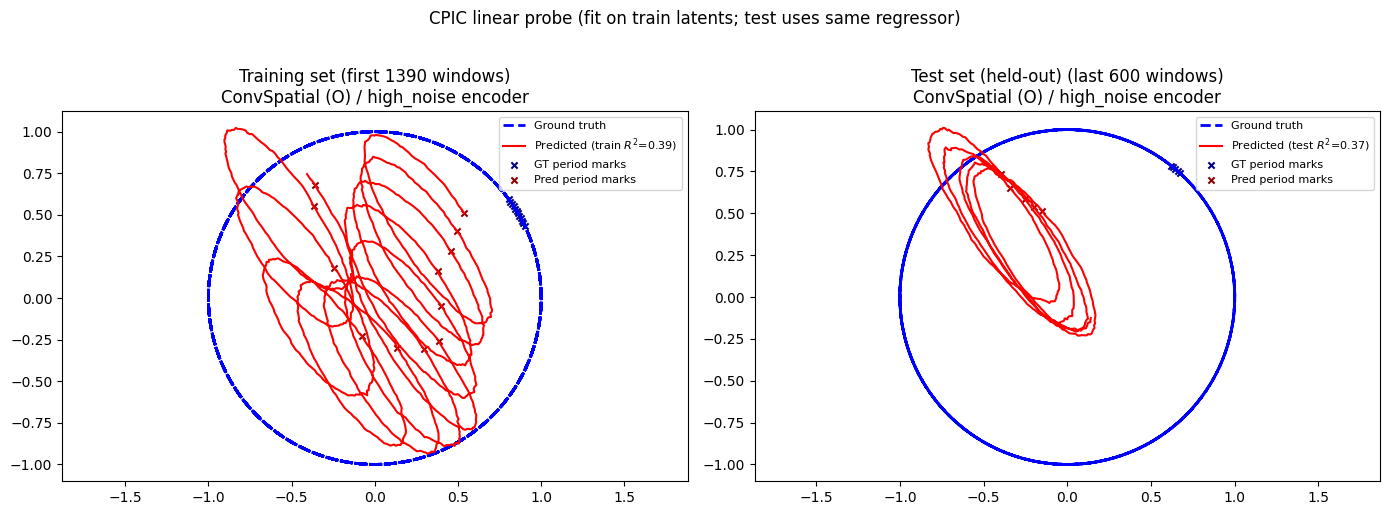

[cleanup] MPS backend active (no torch empty_cache equivalent).
  --- predictive_space='latent' ---
Epoch 0: loss=-0.0591, I_compress_bound=3.2648, I_predictive_bound=0.0591
Epoch 1: loss=-0.3433, I_compress_bound=5.3655, I_predictive_bound=0.3433
Epoch 2: loss=-0.7361, I_compress_bound=5.3885, I_predictive_bound=0.7362
Epoch 3: loss=-1.1269, I_compress_bound=5.3885, I_predictive_bound=1.1270
Epoch 4: loss=-1.4748, I_compress_bound=5.3885, I_predictive_bound=1.4748
Epoch 5: loss=-1.7858, I_compress_bound=5.3885, I_predictive_bound=1.7858
Epoch 6: loss=-2.0681, I_compress_bound=5.3885, I_predictive_bound=2.0681
Epoch 7: loss=-2.3148, I_compress_bound=5.3885, I_predictive_bound=2.3149
Epoch 8: loss=-2.5223, I_compress_bound=5.3885, I_predictive_bound=2.5224
Epoch 9: loss=-2.6857, I_compress_bound=5.3885, I_predictive_bound=2.6858
Epoch 10: loss=-2.8323, I_compress_bound=5.3885, I_predictive_bound=2.8324
Epoch 11: loss=-2.9207, I_compress_bound=5.3885, I_predictive_bound=2.9208
Epoch 12: 

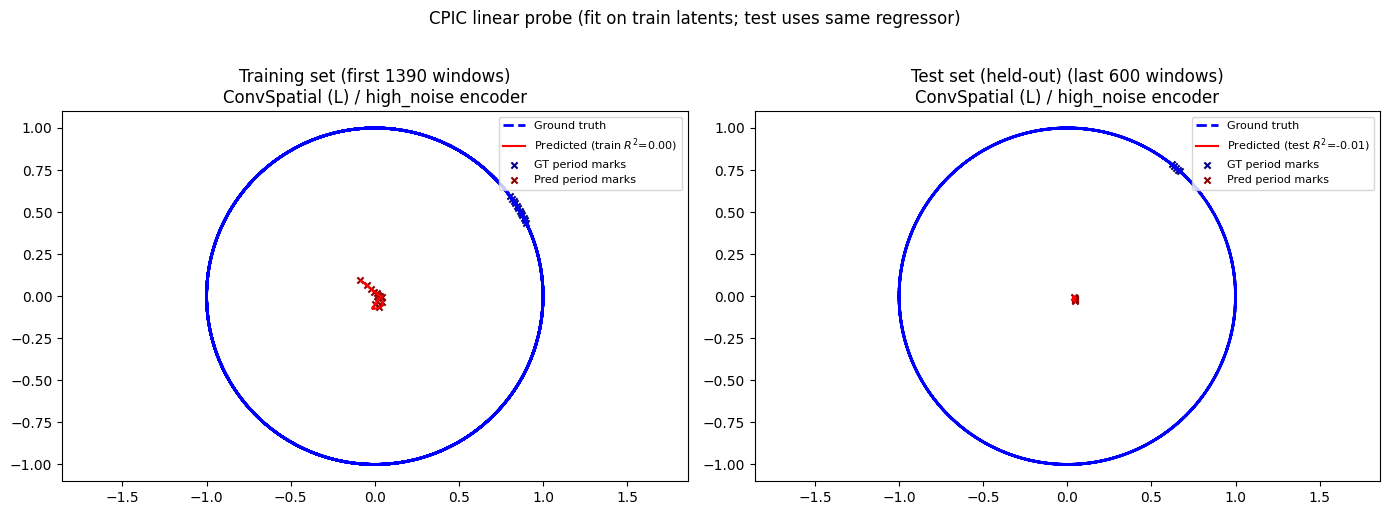

[cleanup] MPS backend active (no torch empty_cache equivalent).


,condition,predictive_space,num_noise,sigma_noise,r2_train,r2_test_x,r2_test_y,r2_test
0,no_noise,observation,0,0.0,0.999806,0.999105,0.999245,0.999175
1,no_noise,latent,0,0.0,0.976357,0.975736,0.975296,0.975516
2,high_noise,observation,120,1.0,0.390393,0.316349,0.433217,0.374783
3,high_noise,latent,120,1.0,0.002676,-0.015785,-0.001660,-0.008722


In [27]:
noise_conditions = [
    {"name": "no_noise", "num_noise": 0, "sigma_noise": 0.0, "seed": 42},
    {"name": "high_noise", "num_noise": 120, "sigma_noise": 1.0, "seed": 42},
]

ablation_rows = []
for cond in noise_conditions:
    print(f"\n=== Noise condition: {cond['name']} ===")
    cond_data, cond_gt, _, _ = generate_drift_diffusion_process_timeseries(
        t_max=2000,
        num_blob=30,
        num_noise=cond["num_noise"],
        orbit_radius=3.0,
        omega=0.05,
        sigma_blob=0.1,
        sigma_noise=cond["sigma_noise"],
        spatial_bounds=10.0,
        seed=cond["seed"],
    )

    cond_t_split = int(0.7 * len(cond_data))
    if cond_t_split <= 2 * T or (len(cond_data) - cond_t_split) <= 2 * T:
        raise ValueError("Invalid split for noise ablation condition.")

    cond_train_data = PastFutureDataset([cond_data[:cond_t_split]], window_size=T)

    for predictive_space, tag in (("observation", "O"), ("latent", "L")):
        print(f"  --- predictive_space={predictive_space!r} ---")
        cpic_ablation = CPIC(
            ydim=2,
            xdim=cond_data.shape[1],
            T=T,
            encoder_params=encoder_params,
            hidden_dim=64,
            beta=1e-5,
            device=device,
            predictive_space=predictive_space,
        )
        cpic_ablation.to(device)

        loss_ablation, I_compress_ablation, I_predictive_ablation = cpic_ablation.fit(
            X=cond_train_data, epochs=80, batch_size=256, lr=2e-4, early_stop=20, verbose=False
        )

        z_train, gt_train = build_past_windows_and_gt(
            cond_data, cond_gt, T, cpic_ablation, t_min=T, t_max=cond_t_split
        )
        z_test, gt_test = build_past_windows_and_gt(
            cond_data, cond_gt, T, cpic_ablation, t_min=cond_t_split, t_max=len(cond_data)
        )

        metrics = evaluate_probe_train_test(
            z_train,
            gt_train,
            z_test,
            gt_test,
            encoder_name=f"ConvSpatial ({tag}) / {cond['name']}",
            period_steps=period_steps,
        )

        ablation_rows.append(
            {
                "condition": cond["name"],
                "predictive_space": predictive_space,
                "num_noise": cond["num_noise"],
                "sigma_noise": cond["sigma_noise"],
                "r2_train": metrics["r2_train"],
                "r2_test_x": metrics["r2_test_x"],
                "r2_test_y": metrics["r2_test_y"],
                "r2_test": metrics["r2_test"],
            }
        )

        cleanup_model_resources(cpic_ablation, loss_ablation, I_compress_ablation, I_predictive_ablation)

ablation_df = pd.DataFrame(ablation_rows)
ablation_df

## ConvParticle2D (Observation predictive space) encoder

`conv_particle2d` reshapes each timestep into a `(num_particles, 2)` tensor (x,y) and applies Conv2d over the particle axis (and optionally across x/y together). This makes the learned kernels interpretable as local patterns over neighboring particles in the x-sorted order at `t=0`.


In [40]:
encoder_params_particle2d = {
    "deterministic": False,
    "encoder_type": "conv_particle",
    "linear_encoder": False,
    "n_layers": 1,
    "activation": "relu",
    # conv over particle axis
    "conv_kernel_size": 5,
    "conv_stride": 1,
    "conv_padding": 2,
    # conv over coordinate axis (1 = separate x/y, 2 = mix x/y)
    "conv_coord_kernel_size": 2,
}

cpic_particle2d_obs = CPIC(ydim=2, xdim=n_spatial, T=T, encoder_params=encoder_params_particle2d, hidden_dim=64, beta=1e-5, device=device, predictive_space="observation")
cpic_particle2d_obs.to(device);

In [41]:
loss, I_compress, I_predictive = cpic_particle2d_obs.fit(X=train_data, epochs=80, batch_size=256, lr=2e-4, early_stop=20)

  1%|▏         | 1/80 [00:00<01:15,  1.04it/s]

Epoch 0: loss=-0.0105, I_compress_bound=1.9613, I_predictive_bound=0.0105


  2%|▎         | 2/80 [00:01<01:00,  1.29it/s]

Epoch 1: loss=-0.0849, I_compress_bound=3.8576, I_predictive_bound=0.0849


  4%|▍         | 3/80 [00:02<00:55,  1.40it/s]

...

Epoch 77: loss=-5.0984, I_compress_bound=5.3885, I_predictive_bound=5.0984


 99%|█████████▉| 79/80 [00:51<00:00,  1.49it/s]

Epoch 78: loss=-5.0897, I_compress_bound=5.3885, I_predictive_bound=5.0897


100%|██████████| 80/80 [00:52<00:00,  1.53it/s]

Epoch 79: loss=-5.1477, I_compress_bound=5.3885, I_predictive_bound=5.1477


ConvSpatialParticle2D (O) - train R^2: x=0.23, y=0.97 | test R^2: x=0.37, y=0.88


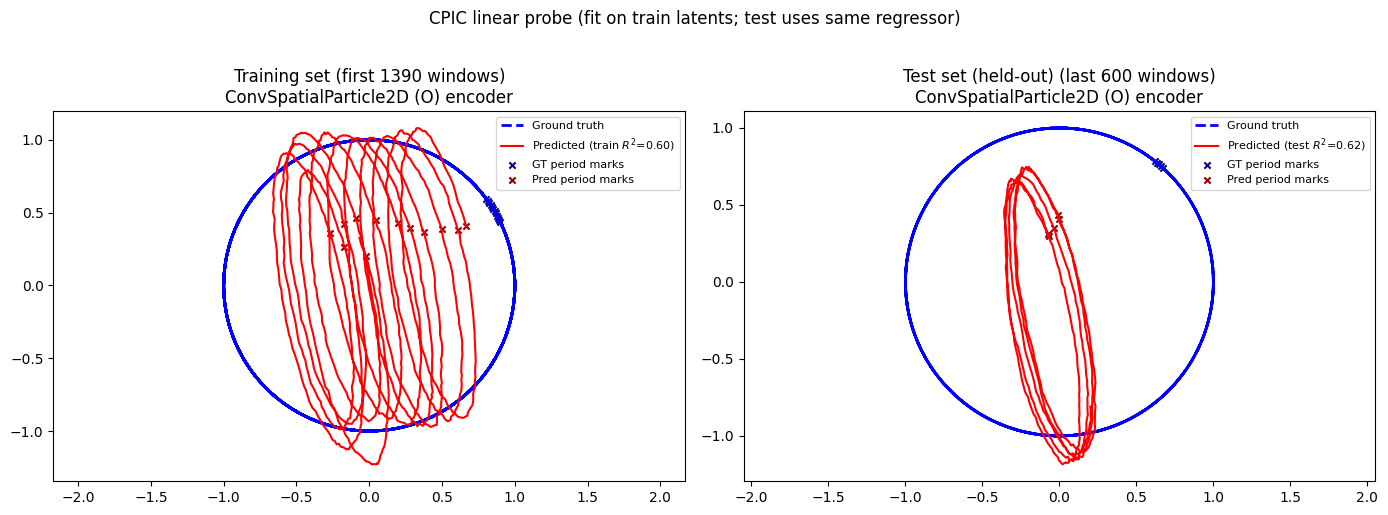

In [42]:
z_train, gt_train = build_past_windows_and_gt(data, gt_latent, T, cpic_particle2d_obs, t_min=T, t_max=t_split)
z_test, gt_test = build_past_windows_and_gt(data, gt_latent, T, cpic_particle2d_obs, t_min=t_split, t_max=len(data))

particle2d_metrics = evaluate_probe_train_test(
    z_train,
    gt_train,
    z_test,
    gt_test,
    encoder_name="ConvSpatialParticle2D (O)",
    period_steps=period_steps,
)

### Kernel / particle analysis (ConvParticle2D)

We visualize the first conv layer’s weights as \(|w|\) and compute a simple per-particle “importance” score by distributing kernel magnitudes back to the particle indices each output position “sees,” analogous to the `conv_spatial` feature-importance approach.


In [43]:
enc_p2d = cpic_particle2d_obs.encoder
layer_idx = 0

if getattr(enc_p2d, "encoder_type", None) != "conv_particle2d":
    print("Skipping kernel analysis: encoder is not conv_particle2d")
else:
    w, meta = enc_p2d.get_filters(layer_idx=layer_idx)
    print(f"Layer {layer_idx} Conv2d weight shape:", w.shape, "padding:", meta["padding"], "stride:", meta["stride"], "kernel:", meta["kernel_size"])

Skipping kernel analysis: encoder is not conv_particle2d


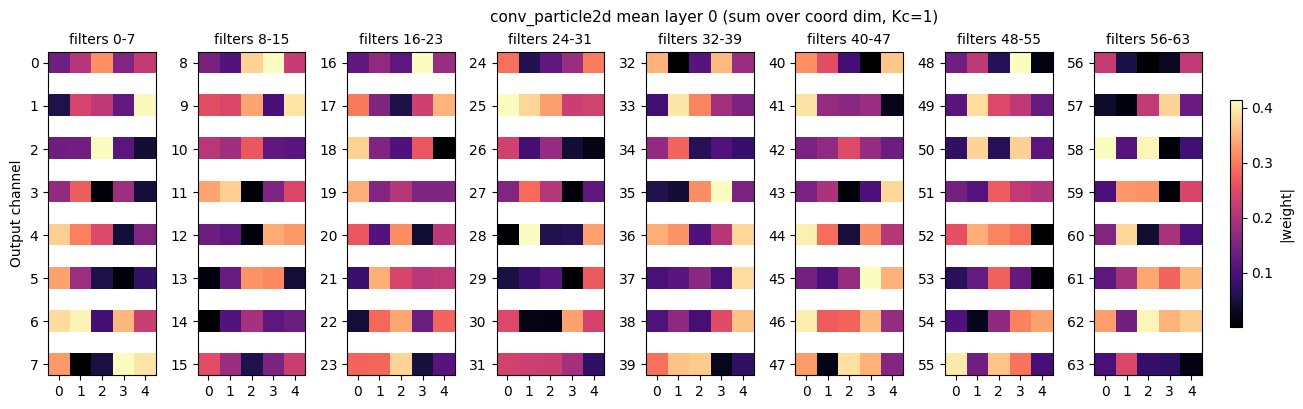

In [44]:
# First-layer weights: (C_out, 1, K_particles, K_coords)
w_mag = np.abs(w[:, 0, :, :])
C_out, Kp, Kc = w_mag.shape

# Heatmap panel: collapse coord dim so we can reuse existing panel plotting helper
w_mag_1d = w_mag.sum(axis=2)  # (C_out, K_particles)
fig, axes = plot_filter_heatmap_panels(
    w_mag_1d,
    gap_rows=1,
    filters_per_panel=8,
    suptitle=f"conv_particle2d mean layer {layer_idx} (sum over coord dim, Kc={Kc})",
)
plt.show()

In [45]:
cleanup_model_resources(cpic_particle2d_obs, loss, I_compress, I_predictive)

[cleanup] MPS backend active (no torch empty_cache equivalent).


## ConvParticle2D (Latent predictive space) encoder

Same encoder as above, but trains CPIC with `predictive_space="latent"` (predicting encoded future latents rather than raw future observations).


In [46]:
cpic_particle2d_latent = CPIC(ydim=2, xdim=n_spatial, T=T, encoder_params=encoder_params_particle2d, hidden_dim=64, beta=1e-5, device=device, predictive_space="latent")
cpic_particle2d_latent.to(device);

In [47]:
loss, I_compress, I_predictive = cpic_particle2d_latent.fit(X=train_data, epochs=80, batch_size=256, lr=2e-4, early_stop=20)

  1%|▏         | 1/80 [00:00<00:53,  1.49it/s]

Epoch 0: loss=0.0002, I_compress_bound=1.2488, I_predictive_bound=-0.0002


  2%|▎         | 2/80 [00:01<00:50,  1.53it/s]

Epoch 1: loss=-0.0209, I_compress_bound=3.1194, I_predictive_bound=0.0210


  4%|▍         | 3/80 [00:01<00:49,  1.54it/s]

...

Epoch 77: loss=-5.1834, I_compress_bound=5.3885, I_predictive_bound=5.1835


 99%|█████████▉| 79/80 [00:51<00:00,  1.49it/s]

Epoch 78: loss=-5.1784, I_compress_bound=5.3885, I_predictive_bound=5.1785


100%|██████████| 80/80 [00:52<00:00,  1.54it/s]

Epoch 79: loss=-5.1861, I_compress_bound=5.3885, I_predictive_bound=5.1862


ConvParticle2D (L) - train R^2: x=0.39, y=0.91 | test R^2: x=0.31, y=0.90


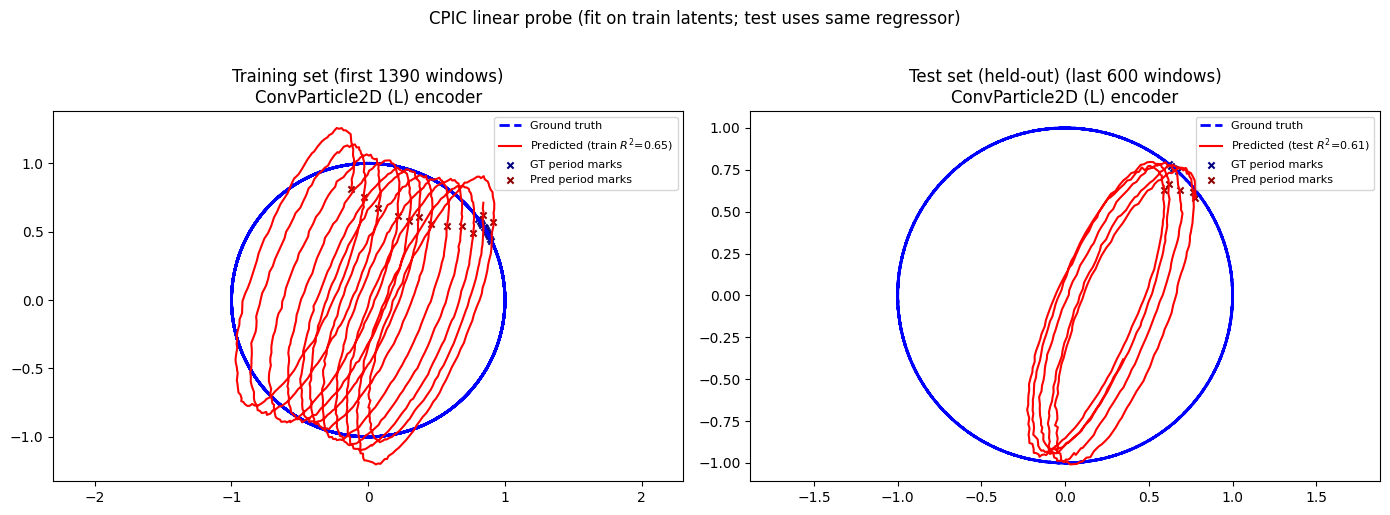

In [48]:
z_train, gt_train = build_past_windows_and_gt(data, gt_latent, T, cpic_particle2d_latent, t_min=T, t_max=t_split)
z_test, gt_test = build_past_windows_and_gt(data, gt_latent, T, cpic_particle2d_latent, t_min=t_split, t_max=len(data))

particle2d_latent_metrics = evaluate_probe_train_test(
    z_train,
    gt_train,
    z_test,
    gt_test,
    encoder_name="ConvParticle2D (L)",
    period_steps=period_steps,
)

### Kernel / particle analysis

In [49]:
enc_p2d_latent = cpic_particle2d_latent.encoder
layer_idx = 0

if getattr(enc_p2d_latent, "encoder_type", None) != "conv_particle2d":
    print("Skipping kernel analysis: encoder is not conv_particle2d")
else:
    w, meta = enc_p2d_latent.get_filters(layer_idx=layer_idx)
    print(f"Layer {layer_idx} Conv2d weight shape:", w.shape, "padding:", meta["padding"], "stride:", meta["stride"], "kernel:", meta["kernel_size"])

Skipping kernel analysis: encoder is not conv_particle2d


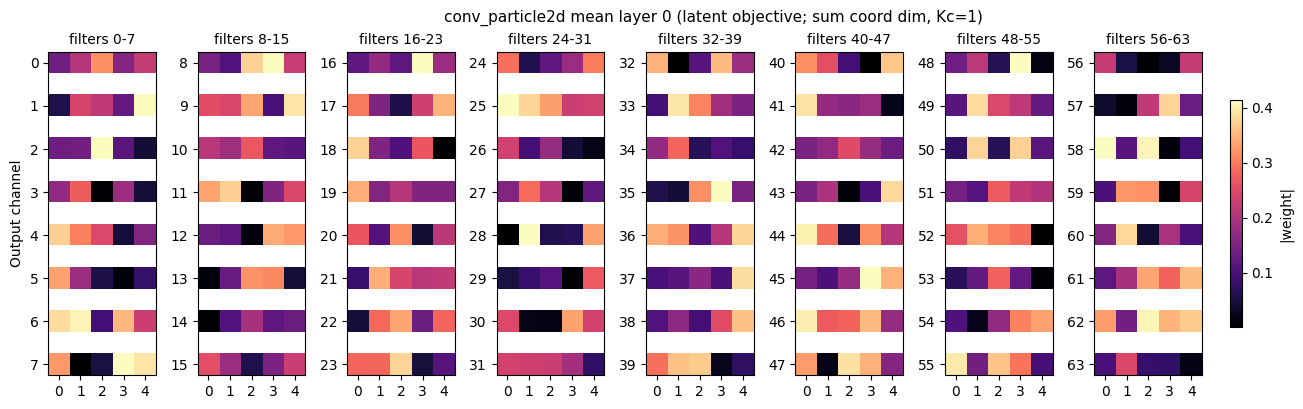

In [50]:
w_mag = np.abs(w[:, 0, :, :])
C_out, Kp, Kc = w_mag.shape
w_mag_1d = w_mag.sum(axis=2)
fig, axes = plot_filter_heatmap_panels(
    w_mag_1d,
    gap_rows=1,
    filters_per_panel=8,
    suptitle=f"conv_particle2d mean layer {layer_idx} (latent objective; sum coord dim, Kc={Kc})",
)
plt.show()

In [51]:
cleanup_model_resources(cpic_particle2d_latent, loss, I_compress, I_predictive)

[cleanup] MPS backend active (no torch empty_cache equivalent).
